# Practicum 1

By submitting this notebook to Gradescope you are acknowledging that you are upholding the Duke honor code that this notebook is representative of the work of all that are on the submission and no one else.

This assessment can be done in teams of two. It represents your pair's work, and only your pair's work to show your all's understanding of the material. This document and your answers are for your pair's eyes only.

This exam is open book, open note, open Internet, open to large language models, and closed to people outside of your team. This means you cannot communicate with someone outside of your pair about the practicum until grades are published, including asking someone through the Internet (like stackoverflow) to receive help.

If you wish to earn an Exemplary (full credit), your plots must be clean and easy to understand. That means ensuring the text of axis labels are not overlapping by using parameters like `aspect` and `height`. Using column names as your axis labels is fine and titles are not required. **In addition, all answers that are clearly plagiarized from the practice exam will be marked as Not Yet**. 

You **may reuse** the results of prior questions (like variables or new columns) in later questions. If you do so, you need to clearly state it for the graders.

Except for the Monte Carlo Simulation problem (question 4), you may **not use** `for` or `while` loops if there are clear ways to do it using libraries and without such loops. In addition, the code must guarantee that the loop will iterate less than 25 times, including if we swap out the data for another data file with 10x more rows. Using such loops will immediately mark your solution as "Not Yet" because one large purpose of this exam is to assess your skills at taking advantage of the data science libraries.

If you think something is ambiguous or some assumption/key information is missing, decide on your own interpretation or any additional assumption and state them clearly.

The grading for this exam will be very lenient in the reasonableness of how you use the data since we do not expect you to have a great understanding of the data set. Moreover, the values in this data set do not necessarily reflect the real world.

# Practicum Update Diff Cell (2 points, if you submit the Update)
If you are not updating your practicum for the Practicum Update, ignore this cell. If you are updating this notebook for the Practicum Update, fill out this template to make clear what you did and did not change.

### Question 1
- updated = ...
- summary: None (replace with your summary if you updated your answer for this question, for example something like "We did not change the code and only changed the writeup to better answer questions 2 and 3.")

### Question 2
- updated = ...
- summary: None (replace with your summary if you updated your answer for this question, for example something like "We cleaned up the code by removing the `==True` and did not change the writeup.")

### Question 3
- updated = ...
- summary: None (replace with your summary if you updated your answer for this question)

### Question 4
- updated = ...
- summary: None (replace with your summary if you updated your answer for this question)

# Overview Note

We recommend scanning through the entire exam before beginning so you have a sense of what each question is asking you to do.

Feel free to add columns to the dataframe and use them throughout the notebook. Just note in your writeup where the code for a particular new column is to make grading easier.

**Using LLMs**: For each question, there is a variable called `q#_llm_flag`. Set this to `True` if you used an LLM to help you with that question and `False` otherwise.

In [11]:
# Standard imports
import numpy as np
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt

# Group Members

In the below cell provide the NetIds as strings of all the people working on this practicum. If you are working solo, write `student2`'s NetId as `'no1'`.

In [12]:
student1 = 'mz248'
student2 = 'al430'

# Data Set: AirBnB Listings

Below is a data set about AirBnB listings in North Carolina. Every row represents a single AirBnB listing.

The meanings of all columns are listed below.

Note: The values in this data set do not necessarily reflect the real world and may be inaccurate.

| Variable | Type | Description |
|----------|------|-------------|
| `id` | int64 | ID for the listing |
| `name` | str | Name of the listing |
| `description` | str | Description of the listing |
| `neighborhood_overview` | str | Overview of the neighborhood the listing is in |
| `host_id` | int64 | ID for the host |
| `host_name` | str | Host's name, could be one or more people, or a company |
| `host_since` | str | Date since being a host |
| `host_location` | str | Where the host is from with format "City, State", state is the state abbreviation |
| `host_about` | str | Description about the host |
| `host_response_time` | str | How quickly the host responds; 4 possible options |
| `host_response_rate` | str | Percent of times host responds as a string |
| `host_acceptance_rate` | str | Percent of times host accepts a booking as a string |
| `host_is_superhost` | bool | Whether the host is a super host |
| `host_listings_count` | int64 | Number of listings the host has in NC |
| `host_total_listings_count` | int64 | Number of listings the host has total |
| `host_has_profile_pic` | bool | Whether the host has a picture in their profile |
| `host_identity_verified` | bool | Whether the host's identity has been verified |
| `neighbourhood` | str | Where the listing is with format "City, State, Country", state is the full state name |
| `neighbourhood_zip` | int64 | The neighborhood's zip code |
| `latitude` | float | Listings latitude |
| `longitude` | float | Listings longitude |
| `property_type` | str | Type of property, not standardized; there are many possible options |
| `room_type` | str | Type of room, 4 possible options |
| `accommodates` | int64 | How many people the listing can have |
| `bathrooms_text` | str | Text description of the bathrooms |
| `bedrooms` | float | Number of bedrooms |
| `beds` | float | Number of beds |
| `amenities` | str | Python formatted list of amenities with no particular order |
| `price` | str | Price of one night as a string |
| `minimum_nights` | int64 | Minimum number of nights for a booking |
| `maximum_nights` | int64 | Maximum number of nights for a booking |
| `availability_365` | int64 | Number of days available throughout the year |
| `review_scores_rating` | float | Mean general rating |
| `review_scores_accuracy` | float | Mean rating about the listing's accuracy |
| `review_scores_cleanliness` | float | Mean rating about the listing's cleanliness |
| `review_scores_checkin` | float | Mean rating about the listing's checkin experience |
| `review_scores_communication` | float | Mean rating about the listing's communication with the host |
| `review_scores_location` | float | Mean rating about the listing's location |
| `review_scores_value` | float | Mean rating about the listing's value |
| `instant_bookable` | bool | Whether the listing is instantly bookable |
| `calculated_host_listings_count` | int64 | A different calculated count of the number of listings by the host |
| `calculated_host_listings_count_entire_homes` | int64 | How many entire homes the host lists |
| `calculated_host_listings_count_private_rooms` | int64 | How many private rooms the host lists |
| `calculated_host_listings_count_shared_rooms` | int64 | How many shared rooms the host lists |

In [13]:
# import data
df = pd.read_csv('listings.csv')
print(df.shape)
df.head()

(3161, 44)


,id,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms
0,108061,Walk to stores/parks/downtown. Fenced yard/Pet...,Walk to town in ten minutes! Monthly rental in...,"I love my neighborhood! Its friendly, easy-goi...",320564,Lisa,2010-12-16,"Asheville, NC",I am a long time resident of Asheville and am ...,within an hour,...,4.70,4.85,4.80,4.84,4.49,False,2,2,0,0
1,155305,Cottage! BonPaul + Sharky's Hostel,<b>The space</b><br />Pet friendly private cot...,"We are within easy walk of pubs, breweries, mu...",746673,BonPaul,2011-06-26,"Asheville, NC",We operate two traveler's hostels located in H...,within an hour,...,4.42,4.83,4.74,4.93,4.55,False,6,1,2,3
2,156805,"Private Room ""Ader"" at BPS Hostel",<b>The space</b><br />Private Rooms at Bon Pau...,"Easy walk to pubs, cafes, bakery, breweries, l...",746673,BonPaul,2011-06-26,"Asheville, NC",We operate two traveler's hostels located in H...,within an hour,...,4.43,4.76,4.61,4.84,4.46,True,6,1,2,3
3,197263,Tranquil Room & Private Bath,"This is a comfy, peaceful and clean room with ...",NaN,961396,Timo,2011-08-12,"Asheville, NC","I'm from Asheville, NC. I'm a yogi, artist and...",within a few hours,...,5.00,4.95,4.92,4.82,4.98,False,2,1,1,0
4,209068,Terrace Cottage,Located in one of Asheville's oldest historic ...,Our beautiful Grove Park Historic District clo...,1029919,Kevin,2011-08-28,"Asheville, NC",Welcome to Terrace Cottage!\r\n\r\nFor fifteen...,within a few hours,...,4.84,5.00,4.98,4.93,4.77,False,1,1,0,0


# Question 1 (24 points: 4 autograded, 20 manually graded)

Do the following:
1. Create a mask that you will use to filter the data:
    1. It must be True for 10%-90% of the data and False otherwise.
    1. You may base the mask on multiple columns, but you do not have to.
    1. Add the mask as a new column to the dataframe.
    1. Put the new column's name in `new_mask_col_name`.
1. Put the fraction of rows kept by the mask in `frac_data_kept`.
1. Use the mask to filter the data and then calculate a single descriptive statistic (e.g., mean, count, median, proportion, etc.) of a **different** column. Put this value in `statistic_mask`.
1. Calculate the same descriptive statistic for the entire data set.  Put this value in `statistic_all`.

**See the written portion of this question to see what you must explain.**

## Answer 1: Code

In [14]:
q1_llm_flag = True

# Clean the price column once and store it as numeric
df['price_clean'] = pd.to_numeric(
    df['price'].str.replace(r'[\$,]', '', regex=True),
    errors='coerce'
)

# Create a meaningful mask: listings that allow stays of one week or less
new_mask_col_name = 'short_stay_listing'
mask = df['minimum_nights'] <= 7

# Add mask as a new column in the dataframe
df[new_mask_col_name] = mask

# Calculate fraction of rows kept by the mask
frac_data_kept = mask.mean()

# Calculate descriptive statistic (mean price) for masked data
statistic_mask = df.loc[mask, 'price_clean'].mean()

# Calculate same statistic for entire dataset
statistic_all = df['price_clean'].mean()

# Leave these here to help with grading
print("New mask's column name:", new_mask_col_name)
print("Fraction of data kept:", frac_data_kept)
print("Descriptive statistic of masked data:", statistic_mask)
print("Descriptive statistic of all data:", statistic_all)

New mask's column name: short_stay_listing
Fraction of data kept: 0.8845302119582411
Descriptive statistic of masked data: 180.8397711015737
Descriptive statistic of all data: 175.02594115786144


<!-- BEGIN QUESTION -->

## Answer 1: Written portion
Do the following:
1. Explain what your mask is filtering for.
1. State the values of and what your descriptive statistics in `statistic_mask` and `statistic_all` are. Explain what these numbers tell you about the data. Are their values surprising? Why or why not?
1. If you did not in the prior subquestions, compare the two values, is one bigger? Which one? Speculate why this is the case.

QUESTION 1 ANSWER

1. The mask filters for listings where `minimum_nights ≤ 7`, meaning the listing allows a stay of one week or less. These listings are generally more flexible and are more suitable for short-term travelers such as tourists or weekend visitors. The mask column, named `short_stay_listing`, is a boolean Series where each row is `True` if the listing allows stays of seven nights or fewer and `False` otherwise. The fraction of rows where the mask is `True` is **0.8845302119582411**, meaning that approximately **88.45% of the listings** in the dataset allow stays of one week or less.

2. The descriptive statistic calculated is the **mean of the column `price_clean`**, which represents the average nightly price of a listing after converting the original price column into numeric values. The mean price for listings that satisfy the mask is **180.8397711015737**, which is stored in `statistic_mask`. The mean price for the entire dataset is **175.02594115786144**, which is stored in `statistic_all`.

3. Comparing these values shows that the mean price for listings allowing short stays (**180.8397711015737**) is slightly higher than the overall mean price (**175.02594115786144**). This suggests that listings that allow shorter stays tend to be somewhat more expensive on average. One possible explanation is that short-stay friendly listings may target travelers who stay for shorter trips, such as tourists or weekend visitors, and may price their listings slightly higher to compensate for higher turnover between guests. However, the difference between the two values is relatively small, so minimum stay requirements do not appear to drastically change the typical listing price in this dataset.

<!-- END QUESTION -->

# Question 2 (25 points: 4 autograded, 21 manually graded)

Assessment goal: Demonstrate an understanding of how to use regular expressions to extract information from strings that are irregular.

Do the following:
1. Use a regular expression(s) to create a new column by extracting information (a substring or number) from an existing column with data of type string.
    1. The existing/original column must have more than 18 unique values. So, do not use something like `room_type`.
    1. The extracted information cannot be from something that is extremely uniform, such as something that is of fixed width and in the same location, like removing "North Carolina" from `neighbourhood` or the `$` from `price`. If you could get it by just slicing all the strings the same way, it is not a good demonstration of using regular expressions.
    1. The extracted information must be information that cannot easily be extracted with methods other than regular expressions (such as creating a `True`/`False` or `"yes"`/`"no"` column by just using `str.contains` or equivalent).
    1. Therefore, the extracted information must be a number or of type string.
    1. Put the name of the column you are extracting from in `org_col_name`.
    1. Put the new column's name in `new_col_name`.
1. Count the number of NaNs in **the original column** and put it in `nan_count_org`.
1. Count the number of NaNs in **your new column** and put it in `nan_count_new`.

**See the written portion of this question to see what you must explain.**

## Answer 2: Code

In [23]:
q2_llm_flag = True

org_col_name = 'name'
new_col_name = 'number_in_name'

# Extract standalone numbers between 2 and 5 digits from listing titles
df[new_col_name] = pd.to_numeric(
    df[org_col_name].str.extract(r'\b(\d{2,5})\b', expand=False),
    errors='coerce'
)

nan_count_org = df[org_col_name].isna().sum()
nan_count_new = df[new_col_name].isna().sum()

print('Original column:', org_col_name)
print('Unique values in original column:', df[org_col_name].nunique())
print('New column:', new_col_name)
print('Head of old column:')
print(df[org_col_name].head(5))
print('Head of the non-NaN values of the new column:')
print(df[new_col_name].dropna().head(5))
print('Count of NaNs in original column:', nan_count_org)
print('Count of NaNs in new column:', nan_count_new)
print('% NaNs in new column:', 100 * nan_count_new / df.shape[0])

Original column: name
Unique values in original column: 3143
New column: number_in_name
Head of old column:
0    Walk to stores/parks/downtown. Fenced yard/Pet...
1                   Cottage! BonPaul + Sharky's Hostel
2                    Private Room "Ader" at BPS Hostel
3                         Tranquil Room & Private Bath
4                                      Terrace Cottage
Name: name, dtype: object
Head of the non-NaN values of the new column:
14       90.0
25    28803.0
36       10.0
51       11.0
55       10.0
Name: number_in_name, dtype: float64
Count of NaNs in original column: 0
Count of NaNs in new column: 2887
% NaNs in new column: 91.33185700727618


<!-- BEGIN QUESTION -->

## Answer 2: Written portion
Do the following:
1. Explain what the code you wrote in the code cell does.
1. State how many NaNs there are in the original and new columns. Provide a possible reason why the NaNs are/are not there.
1. If you did not discuss this in the prior subquestion, why do the original and new columns have the same or not the same number of NaNs?

**ANSWER** 

The code extracts numeric substrings from the `name` column using the regular expression pattern `\b(\d{2,5})\b`. The `name` column contains the titles of Airbnb listings, which are free-text strings with many unique values and irregular structure. The pattern `\d{2,5}` matches a sequence of **two to five consecutive digits**, while the `\b` symbols indicate **word boundaries**, ensuring that the digits appear as a standalone number rather than being embedded within a longer string. The `str.extract` method applies this pattern to each listing title and returns the **first substring that matches the pattern**. The extracted value is then converted to numeric format and stored in the new column `number_in_name`. This approach requires regular expressions because the position of numbers within listing titles varies across strings and cannot be reliably extracted using simple slicing or fixed string positions.

The original column `name` contains **0 NaN values**, meaning every listing in the dataset has a title. The new column `number_in_name` contains **2887 NaN values**, which occurs whenever a listing title does not contain a numeric substring that matches the regular expression pattern. In other words, if a title does not include a number consisting of two to five digits, the regular expression does not find a match and `str.extract` returns NaN for that row. 
The `\b` characters ensure that the number appears as a standalone value rather than being part of a longer string of digits.


The original and new columns therefore have **different numbers of NaN values**. The original column only contains NaN values if a listing title itself is missing, which does not occur in this dataset. In contrast, the new column contains NaN values whenever a listing title exists but does not contain a standalone number with two to five digits. This explains why the new column contains a large number of NaN values, since most Airbnb listing titles consist primarily of descriptive text rather than numeric identifiers.



<!-- END QUESTION -->

# Question 3 (25 points: 4 autograded, 21 manually graded)

For this question, do the following:

1. `col_cat` column - Create a new column that labels each row with some kind of category. Put the name of your new column in `col_cat`. Other requirements include:
   1. The column needs at least 2 categories and cannot have more than 18.
   1. You may use the results of the regular expression question, just state as much in the write up.
   1. If you wish, you may filter to reduce the number of categories or the data you are visualizing. For example, you can filter to make your plot more legible. You must have at least 100 rows in the dataframe you use to create your plot.
1. Put in `val_counts` a Series where the key/index are the categories of `col_cat` and the values are the number of rows with that category.
1. Use `relplot`, `displot`, or `catplot` to create a plot using the `col_cat` column and **at least one other column** ([documentation figure](https://seaborn.pydata.org/tutorial/function_overview.html#figure-level-vs-axes-level-functions "‌")).
1. Put the data you used for the plot in `table3`. This table should include **only** the data you used and no other columns nor rows.

**Note**: Remember, your plot must be legible to be able to earn an Exemplary mark.

**See the written portion of this question to see what you must explain.**

## Answer 3: Code

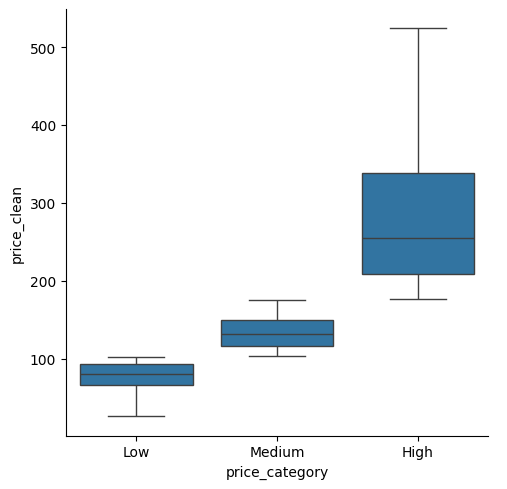

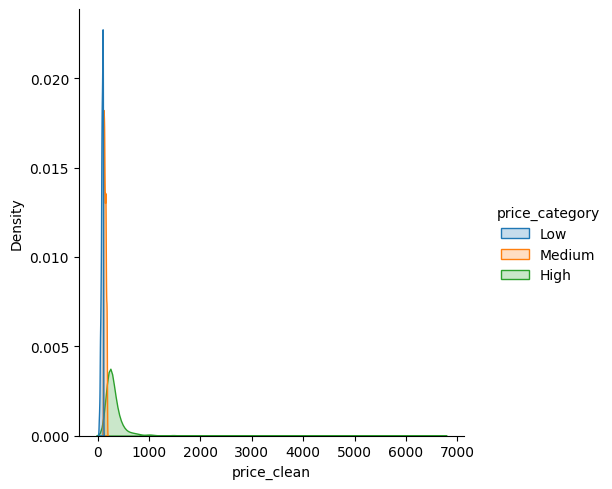

In [26]:
q3_llm_flag = True

# Clean price column
df['price_clean'] = pd.to_numeric(
    df['price'].replace(r'[\$,]', '', regex=True),
    errors='coerce'
)

# Create categorical column using price quantiles
df['price_category'] = pd.qcut(
    df['price_clean'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# Store column name in col_cat
col_cat = 'price_category'

# Only keep columns used in the visualization
table3 = df[[col_cat, 'price_clean']].dropna()

# Value counts of categories
val_counts = table3[col_cat].value_counts()

# Boxplot comparing price distributions
sns.catplot(
    data=table3,
    x=col_cat,
    y='price_clean',
    kind='box',
    showfliers=False
)

# KDE distribution plot
sns.displot(
    data=table3,
    x='price_clean',
    hue=col_cat,
    kind='kde',
    fill=True,
    common_norm=False
)

<!-- BEGIN QUESTION -->

## Answer 3: Written portion
Explain the following:
1. What is the code doing? Include:
    1. What is `col_cat`? What do the categories in it mean? How did you create it?
    1. How you filtered and why you chose to keep the data you did. If you did not filter at all, just state as much.
1. Explain generally what the plot is showing.
1. Pick a single spot on the plot and describe it by filling out the sentence "The \_\_ on the chart means \_\_ ." (you may use these exact words)
    1. Make sure it is clear what spot you are referring to and you are "pointing" it out without using its data values (otherwise, that's like defining a word while using the word in the definition). For example, "the top right blue dot" or "the shortest red bar," as opposed to "the top dot for AirBnBs that are Private rooms."
    1. If using something like a histogram, be precise about what is inclusive vs. exclusive. For example, “it includes up to 10” is not the same as “it includes up to and including 10.”
    1. If using a boxplot, make sure to mention multiple lines/parts of the boxes and note any outliers.
1. Why did you choose `relplot`/`displot`/`catplot` and use any deviations from the default behavior of that function? Discuss this at least partially in terms of the insight you sought from the plot.
1. Why the other `seaborn` functions would have been less useful to show you what you wanted to see OR why they are equally viable?

**ANSWER**

1. The code analyzes Airbnb listing prices by creating a categorical variable called `price_category`, whose name is stored in the variable `col_cat`. This column divides listings into three groups: **Low**, **Medium**, and **High** price categories. These categories were created using `pd.qcut` on the numeric column `price_clean`, which splits the price data into three equal-sized groups based on quantiles. This means approximately one third of the listings fall into each category depending on their relative price level. I did not filter the dataset other than removing rows with missing values in the columns used for the visualization (`price_category` and `price_clean`). The resulting dataset contains **3161 rows**, which is large enough to make the plots legible and representative.

2. The boxplot shows how listing prices are distributed across the three price categories. Each box summarizes the distribution of `price_clean` values within one category. The KDE plot displays the estimated probability density of prices for each category, allowing us to see where prices are concentrated and how the distributions differ. From the boxplot we can see that prices increase clearly across the categories: the Low category has prices mostly below about $100, the Medium category centers around roughly $130–$150, and the High category includes much larger prices with a wider spread.

3. **The center horizontal line inside the middle box of the chart means the median price of listings in the middle price category.** In the figure, that median appears around **$135**. The bottom edge of that box represents the first quartile (approximately $120), and the top edge represents the third quartile (approximately $150). This means that the middle 50% of listings in that category have prices roughly between $120 and $150. The vertical lines extending above and below the box show the spread of prices excluding outliers. Outliers are not displayed in this plot because the parameter `showfliers=False` was used when creating the boxplot.

4. I chose to use `catplot` with `kind="box"` because it provides a clear summary of how a numeric variable (`price_clean`) varies across categorical groups (`price_category`). Boxplots allow us to easily compare medians, quartiles, and the spread of values across groups, which helps reveal how prices differ between low-, medium-, and high-priced listings. I also used `displot` with `kind="kde"` and `hue=price_category` to visualize the underlying density of prices for each group. The KDE plot reveals that the High price category has a long right tail, meaning a small number of listings have very large prices compared to the rest.

5. Other seaborn figure-level functions such as `relplot` would be less useful for this analysis because `relplot` is designed to show relationships between numeric variables, such as scatterplots or line plots. In this problem we are comparing the distribution of a numeric variable across categorical groups rather than examining relationships between two numeric variables. While `displot` and `catplot` are both appropriate for distribution analysis, `catplot` is particularly useful for comparing summary statistics between categories, whereas `displot` focuses on visualizing the full shape of the distributions.

<!-- END QUESTION -->

# Question 4 (25 points: 4 autograded, 21 manually graded)

In this question, you will run a Monte Carlo Simulation. Your code will sample a subset of listings. Describe a scenario and then calculate the probability of that scenario happening with the following constraints:
1. Use at least 2 columns of data as part of your scenario.
1. The scenario should have some kind of inequality in it, such as "The mean cost of AirBnBs in Fletcher is more than Asheville."
1. The scenario should involve more than one AirBnB.
1. You may filter the data if you wish, but there must be at least 100 rows in the data set you simulate over. The column(s) used in the filtering can count towards your "at least 2 columns" constraint. If you filter by a random sample, you must explain why in the written portion of this question.
1. Run enough simulations that you are confident in your answer within 0.1% (this code prints things as a decimal, so 0.1% is the third digit after the decimal). Do not change the `count` and `sims` variable names. The autograder uses these to do its sanity check.

**See the written portion of this question to see what you must explain.**

**Note**: You are allowed to use a `for` or `while` loop for this question.

## Answer 4: Code

In [17]:
q4_llm_flag = True

# Scenario: Probability that a randomly selected Asheville Airbnb is more expensive than a non-Asheville Airbnb.
# Preprocess price column only once
prices = pd.to_numeric(df['price'].replace('[\$,]', '', regex=True), errors='coerce')

# Filter once for efficiency
loc = df['host_location'].fillna('')
ash_mask = loc.str.lower().str.contains('asheville')
notash_mask = ~ash_mask

ash_prices = prices[ash_mask].dropna().values
notash_prices = prices[notash_mask].dropna().values

assert len(ash_prices) >= 50 and len(notash_prices) >= 50, "Need at least 50 rows in each pool"

sims = 100_000  # Large N for confidence
# Vectorized sampling for efficiency
ash_samples = np.random.choice(ash_prices, sims)
notash_samples = np.random.choice(notash_prices, sims)

count = np.sum(ash_samples > notash_samples)

for i in range(1000, sims+1, 1000):
    if i <= sims:
        print(i, np.sum(ash_samples[:i] > notash_samples[:i]) / i)

# Leave this here to help with grading.
print('Final result:', count/sims)

1000 0.447
2000 0.4285
3000 0.436
4000 0.4385
5000 0.4316
6000 0.43433333333333335
7000 0.43842857142857145
8000 0.4395
9000 0.4411111111111111
10000 0.4415
11000 0.44227272727272726
12000 0.44208333333333333
13000 0.4423076923076923
14000 0.4432857142857143
15000 0.44326666666666664
16000 0.44175
17000 0.4423529411764706
18000 0.44155555555555553
19000 0.4417894736842105
20000 0.44165
21000 0.44133333333333336
22000 0.44095454545454543
23000 0.4409565217391304
24000 0.4422916666666667
25000 0.44324
26000 0.4426538461538462
27000 0.44237037037037036
28000 0.443
29000 0.4432068965517241
30000 0.4428666666666667
31000 0.44261290322580643
32000 0.4435
33000 0.44357575757575757
34000 0.4442058823529412
35000 0.4443714285714286
36000 0.44433333333333336
37000 0.44451351351351354
38000 0.4443157894736842
39000 0.44471794871794873
40000 0.445125
41000 0.44478048780487806
42000 0.44492857142857145
43000 0.44434883720930235
44000 0.4446136363636364
45000 0.44453333333333334
46000 0.444195652173

<!-- BEGIN QUESTION -->

## Answer 4: Written portion
Do the following:
1. Provide a 1-3 sentence explanation of the scenario. Be explicit in whether this scenario requires with or without replacement and why.
1. State the probability your simulation found, rounded to the nearest 0.1%, and explain why you are confident in your answer.

1. In this scenario, we estimate the probability that a randomly selected Airbnb listing with `host_location` containing Asheville has a higher nightly price than a listing whose `host_location` does not contain Asheville. This simulation is with replacement because each draw is independent across trials, so the same listing can be selected again in different simulations. The law of large numbers ensures that as the number of simulations increases, the empirical probability converges to the true sampling probability under the dataset.
2. My simulation found a probability of about 44.4% (final estimate `0.44353`, rounded to the nearest 0.1%), meaning that there's slightly less than a 50-50 chance that an Asheville Airbnb is more expensive than a non-Asheville Airbnb, based on this dataset. I am confident in this estimate because the probability was derived from 100,000 simulated pairwise comparisons, providing a large sample size. Additionally, the running estimate stabilized to the third decimal place as more simulations were performed, indicating precision and reliability at the 0.1% level. Using such a high number of iterations greatly reduces sampling noise and increases the trustworthiness of the final result for decision making or further statistical inference.

<!-- END QUESTION -->

# AI Disclosure (1 point)
Use the [Artificial Intelligence Disclosure (AID) Framework](https://crln.acrl.org/index.php/crlnews/article/view/26548/34482) to explain your use of AI on this exam. Keep in mind the other examples on the class's policy web page.

## My AI Disclosure
*Artificial Intelligence Tools*: ChatGPT v5.2 via chatgpt.com. 
*Code Generation*
Used to brainstorm possible approaches for data categorization and to review appropriate pandas and seaborn function usage. All final code was written, adapted, and verified by us to ensure correctness and alignment with the exam requirements.

*Debugging*: Used to help identify and resolve syntax errors and logic issues while ensuring correct functionality, especially with Question 4 to help make it more effective and to debug better in general. 

*Writing—Review & Editing*: We used AI tools, such as ChatGPT, to help us improve the clarity and conciseness of our written explanations. The AI was primarily used for educational guidance during the editing process, such as suggesting alternative phrasing or pointing out areas that could be clearer or more concise. However, all substantive interpretations, analytical decisions, and conclusions are entirely our own. We relied on the AI only as a minor aid to ensure our responses were well-written and communicated our analysis effectively.


## Submitting

You should make sure any code that you write to answer the questions is included in this notebook. You are **strongly encouraged** to go to the Kernel option and choose **"Restart & Run All"**  before submission. Double check that your entire notebook runs correctly and generates the expected output. Finally, make sure to save your work (timestamp at the top tells you the last checkpoint and whether there are unsaved changes). When you finish, submit your assignment at [Gradescope](http://gradescope.com/ "‌"). **Submissions not prepared correctly as above may lose points.**